## Objective and Data

This notebook performs exploratory data analysis (EDA) for a customer churn prediction project. The goals are to understand:

- The target variable (`Churn Label`)
- Data quality issues and missingness patterns
- Associations between candidate features and churn
- Potential sources of target leakage

The dataset is a customer-level snapshot rather than a full longitudinal customer history. Therefore, this analysis should be interpreted as a retrospective classification study. Observed patterns are useful for feature selection and model building, but they should not be interpreted as causal effects or as proof of future production performance.


## Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'jupyterlab+plotly_mimetype'

from pySankey.sankey import sankey
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

### Loading dataset

The raw dataset contains 7,043 customer records and 50 columns. The preview below is used only to confirm the schema, data types, and a few representative records before the audit begins.

In [2]:
df = pd.read_csv('../data/raw.csv')
display(df.head())

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


## Data dictionary and feature audit

This section reviews the dataset structure, summarizes data types, and identifies columns that should be excluded from predictive modeling to avoid leakage.

In [3]:
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes.value_counts())

# Column groups
id_cols = ["Customer ID"]

target_cols = ["Churn Label"]

post_outcome_cols = [
    "Customer Status",
    "Churn Score",
    "Churn Category",
    "Churn Reason",
]

geographic_cols = [
    "Country",
    "State",
    "City",
    "Zip Code",
    "Latitude",
    "Longitude",
]

candidate_features_pre_audit = [
    col for col in df.columns
    if col not in id_cols + target_cols + post_outcome_cols + geographic_cols
]

print("\nCandidate features before final leakage policy:")
print(candidate_features_pre_audit)

display(df[candidate_features_pre_audit].info())

Shape: (7043, 50)

Column types:
str        31
int64      11
float64     8
Name: count, dtype: int64

Candidate features before final leakage policy:
['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'CLTV']
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count 

None

At this stage, the list above is only a preliminary set of candidate predictors after removing identifiers, explicit post-outcome fields, and high-granularity geography. Additional exclusions may still be made later based on leakage risk, practical usefulness, or modeling policy.

## Target variable: `Churn Label`

`Churn Label` indicates whether the customer churned (`Yes`) or did not churn (`No`). This is the binary outcome variable that the downstream classification models will predict.

Because churners represent a minority of customers, the dataset is moderately imbalanced. This matters when choosing evaluation metrics later: precision, recall, F1-score, PR-AUC, and ROC-AUC are more informative than accuracy alone.


In [4]:
churn_prop = df['Churn Label'].value_counts().to_frame().reset_index().set_axis(['Churned', 'Count'], axis=1)
churn_prop['Percentage'] = [str(round((i/churn_prop['Count'].sum()) * 100, 2)) + '%' for i in churn_prop['Count']]

fig = px.bar(churn_prop, x='Churned', y='Count',
             text_auto=False,
             color_discrete_map={'Yes': "#D83C28", 'No': "#12562a"},
             color='Churned',
             text=['''{}<br>({})'''.format(count, perc) for count, perc in zip(churn_prop['Count'], churn_prop['Percentage'])])

fig.update_layout(template='plotly_white',
                  autosize=False,
                  width=400, 
                  height=700,
                  margin=dict(l=50, r=50, b=50, t=50, pad=10),
                  title=dict(text='Churn Proportions', x=0.5),
                  showlegend=False)

fig.update_traces(textposition='outside', cliponaxis=False)
fig.show()
fig.write_image('../images/churn_prop.svg')

The class distribution shows that approximately 26.5% of customers churned, while about 73.5% did not churn. This is a moderate class imbalance rather than an extreme one, but it is still large enough that model evaluation should rely on imbalance-aware metrics such as precision, recall, F1-score, PR-AUC, and ROC-AUC rather than accuracy alone.

## Data quality and missingness

Missing values in this dataset come from more than one mechanism. Some are likely structural, meaning they are missing because the field is not applicable to a customer. Others may require explicit treatment through imputation or missing-indicator features during modeling.

In [5]:
# Missing values
missing = df.isna().sum()
missing_pct = np.round((missing / len(df)) * 100, 2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct,
}).sort_values('missing_pct', ascending=False)

display(missing_df[missing_df['missing_count'] > 0])


,missing_count,missing_pct
Churn Reason,5174,73.46
Churn Category,5174,73.46
Offer,3877,55.05
Internet Type,1526,21.67


In [6]:
missing_plot_df = (
    missing_df[missing_df['missing_count'] > 0]
    .reset_index()
    .rename(columns={'index': 'feature'})
)

missing_plot_df['label'] = (
    missing_plot_df['missing_count'].astype(int).astype(str)
    + ' ('
    + missing_plot_df['missing_pct'].round(2).astype(str)
    + '%)'
)

fig = px.bar(
    missing_plot_df,
    y='feature',
    x='missing_pct',
    text='label',
    color='missing_pct',
    color_continuous_scale='RdBu',
    labels={
        'missing_pct': 'Missing %',
        'feature': 'Feature',
    },
    title='Missing Values by Feature'
)

fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(
    width=1000,
    height=550,
    template='plotly_white',
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5,
    coloraxis_showscale=False,
    #xaxis_tickangle=-45
)
fig.update_xaxes(automargin=True)
fig.update_yaxes(automargin=True)

fig.show()
fig.write_image('../images/missing_values.svg')

In [7]:
# Duplicates
print('Number of duplicate rows:', df.duplicated().sum())

# Near-constant columns
nunique = df.nunique()
near_constant = nunique[nunique <= 1].index.tolist()
binary_cols = nunique[nunique == 2].index.tolist()
print("\nNear-constant:", near_constant)
print('\nBinary:', binary_cols)


Number of duplicate rows: 0

Near-constant: ['Country', 'State', 'Quarter']

Binary: ['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Referred a Friend', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Paperless Billing', 'Churn Label']


There are four columns with missing values:

- `Churn Reason` and `Churn Category` have high missingness because they are only populated for churned customers. These fields are post-outcome variables and must not be used for predictive modeling.
- `Offer` has substantial missingness and may require imputation or an explicit “Missing” category during modeling.
- `Internet Type` is missing for some customers, likely because internet service is not available or not subscribed. This missingness may be structurally meaningful and can be handled through categorical imputation.

Not all missing values indicate poor data quality. In several cases, missingness itself reflects business logic and may carry information.


## Univariate and bivariate analysis

The following sections examine distributions and churn relationships for selected variables. Features were chosen based on business relevance, potential predictive signal, and representation across demographics, tenure, service usage, product configuration, and spending behavior.


In [8]:
imp_cat = ['Married', 'Offer', 'Phone Service', 'Internet Type', 'Online Security', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Contract', 'Paperless Billing', 'Payment Method']
for col in imp_cat:
    fig = px.pie(df, names=col)
    fig.update_layout(width=500, height=450, margin=dict(l=20, r=10, b=20, t=60, pad=20), title=dict(text=f'Distribution of {col}', x=0.5))
    fig.show()

In [9]:
imp_num = ['Age', 'Number of Dependents', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Long Distance Charges', 'Total Revenue', 'CLTV']
for col in imp_num:
    fig = px.histogram(df, x=col, nbins=30)
    fig.update_layout(template='plotly_white', width=700, height=450, title=dict(text=f'Distribution of {col}', x=0.5))
    fig.show()

## Churn rates by key categorical features

In [10]:
def churn_rate_by_category(df, feature, target='Churn Label'):
    table = (
        df.groupby(feature)[target]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .mul(100)
        .rename(columns={'No': 'Stayed (%)', 'Yes': 'Churned (%)'})
        .sort_values('Churned (%)', ascending=False)
    )
    return table

In [11]:
key_cat_features = [
    'Contract',
    'Payment Method',
    'Internet Type',
    'Offer',
    'Online Security',
    'Internet Service',
]

for feature in key_cat_features:
    display(churn_rate_by_category(df, feature).round(2))

Churn Label,Stayed (%),Churned (%)
Contract,,
Month-to-Month,54.16,45.84
One Year,89.29,10.71
Two Year,97.45,2.55


Churn Label,Stayed (%),Churned (%)
Payment Method,,
Mailed Check,63.12,36.88
Bank Withdrawal,66.00,34.00
Credit Card,85.52,14.48


Churn Label,Stayed (%),Churned (%)
Internet Type,,
Fiber Optic,59.28,40.72
Cable,74.34,25.66
DSL,81.42,18.58


Churn Label,Stayed (%),Churned (%)
Offer,,
Offer E,47.08,52.92
Offer D,73.26,26.74
Offer C,77.11,22.89
Offer B,87.74,12.26
Offer A,93.27,6.73


Churn Label,Stayed (%),Churned (%)
Online Security,,
No,68.67,31.33
Yes,85.39,14.61


Churn Label,Stayed (%),Churned (%)
Internet Service,,
Yes,68.17,31.83
No,92.60,7.40


**Contract**:
- Month-to-month (45.84%) customers have a much higher churn rate than those on one-year or two-year contracts.
- This suggests contract commitment is strongly associated with retention, though the relationship is descriptive, not causal.

**Payment Method**:
- Customers who chose the payment method of mailed check (36.88%) and bank withdrawal (34%) have higher churn rate than the ones who opted to use credit card.
- This suggests that credit card payment method highly associated with retention, and this might be causal (although more information is required to tell this with certainity).

**Internet Type**:
- Customer who chose Fiber Optic have the highest churn rate (40.72%), followed by cable (25.66%).

**Offer**:
- Customer with offer E have the highest churn rate (52.92%), offer D with churn rate of 26.74%, offer C with churn rate of 22.89%.
- This suggest that the customer with Offer E have most likly to churn.

**Online Secrity**:
- Customer opted for Online security have higher churn rate (31.33%) than those who didn't opted it (14.61%).

**Internet Service**:
- Customer that have an Internet Service have higher churn rate (31.83%) than those who don't have Internet Service (7.4%).

## Numeric features and churn

In [12]:
num_features = [
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Total Revenue',
    'CLTV'
]

target = 'Churn Label'

for feature in num_features:
    fig = px.box(data_frame=df, x=target, y=feature, color_discrete_sequence=['#D83C28','#12562a'], color=target)
    fig.update_layout(template='plotly_white', width=900, height=500, title=dict(text=f'{feature} by {target}', x=0.5))
    fig.show()

Key visual patterns from the numeric distributions:

- Customers with shorter tenure tend to show higher churn in this dataset.
- Customers with higher monthly charges appear more likely to churn, although this relationship may interact with service mix and contract type.
- `Total Charges` and `Total Revenue` generally increase with tenure, so lower values among churners may partly reflect shorter customer histories rather than lower value per month.
- `CLTV` differs across churn groups, but because it is partly model-derived and highly related to the business outcome, it should be treated carefully in downstream modeling decisions.
- These patterns are descriptive associations, not causal effects.

## Statistical association analysis

For selected categorical variables, I use chi-square tests of independence and Cramér’s V to assess the strength of association with churn. The chi-square test indicates whether the association is statistically detectable in the sample, while Cramér’s V summarizes the effect size.

Because some variables contain missing values, the effective sample size (`n`) differs across features.


In [13]:
def cramers_v(table):
    chi2, p_value, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

def chi2_test_and_cramers_v(df, feature, target='Churn Label'):
    table = pd.crosstab(df[feature], df[target])
    chi2, p_value, dof, _ = chi2_contingency(table)
    v = cramers_v(table)
    return {
        'feature': feature,
        'chi2': chi2,
        'dof': dof,
        'p_value': p_value,
        'cramers_v': v,
        'n': table.to_numpy().sum()
    }

In [14]:
cat_features_for_test = [
    'Contract',
    'Payment Method',
    'Internet Type',
    'Offer',
    'Online Security',
    'Internet Service',
    'Gender',
    'Senior Citizen',
    'Married',
    'Dependents',
]

results = []

for feature in cat_features_for_test:
    res = chi2_test_and_cramers_v(df, feature, target='Churn Label')
    results.append(res)

stats_df = pd.DataFrame(results).sort_values('cramers_v', ascending=False)
display(stats_df)

,feature,chi2,dof,p_value,cramers_v,n
0,Contract,1445.293243,2,0.000000e+00,0.452720,7043
3,Offer,488.635809,4,1.922257e-104,0.391309,3166
9,Dependents,433.734379,1,2.500972e-96,0.247892,7043
5,Internet Service,364.519799,1,2.920300e-81,0.227204,7043
1,Payment Method,337.831161,2,4.374168e-74,0.218380,7043
2,Internet Type,258.810664,2,6.309258e-57,0.215772,5517
4,Online Security,205.633104,1,1.232098e-46,0.170467,7043
7,Senior Citizen,159.426300,1,1.510067e-36,0.149991,7043
8,Married,158.733382,1,2.139911e-36,0.149663,7043
6,Gender,0.484083,1,4.865787e-01,0.000000,7043


The strongest observed categorical associations with churn are `Contract`, `Offer`, `Dependents`, `Internet Service`, `Payment Method`, and `Internet Type`, based on a combination of chi-square significance and Cramér’s V effect size.

`Gender` shows virtually no association with churn in the displayed results (`p ≈ 0.487`, `Cramér’s V ≈ 0.00`), so it should not be described as a meaningful churn discriminator in this dataset.

These tests quantify association, not causal importance, and they should be interpreted alongside business logic and modeling performance.


## Leakage audit and modeling policy

Before modeling, it is important to remove variables that would leak information about the target or provide unrealistic advantages that would not be available at prediction time.

The main exclusion groups are:

- **Identifiers** such as `Customer ID`, which carry no stable predictive meaning.
- **Post-outcome variables** such as `Customer Status`, `Churn Score`, `Churn Category`, and `Churn Reason`, which are defined after or alongside the churn outcome.
- **High-granularity geography** such as `City`, `Zip Code`, `Latitude`, and `Longitude`, which may capture location-specific patterns but are not essential here and can reduce model generalizability.
- **Policy-based exclusions** such as `Satisfaction Score`, if treated as too close to the outcome or too likely to reflect post-hoc customer experience.

The goal is to produce a realistic feature set that could plausibly be used before churn occurs.

In [15]:
leakage_columns = {
    'identifiers': ['Customer ID'],
    'target': ['Churn Label'],
    'post_outcome': [
        'Customer Status',
        'Churn Score',
        'Churn Category',
        'Churn Reason',
    ],
    'geographic': [
        'Country',
        'State',
        'City',
        'Zip Code',
        'Latitude',
        'Longitude',
    ],
    'additional': ['Satisfaction Score'],
}

all_leakage = sum(leakage_columns.values(), [])

print('Columns to exclude from modeling:')
print(all_leakage)

print('\nRemaining candidate features:')
candidate_features = [col for col in df.columns if col not in all_leakage]
print(candidate_features)

Columns to exclude from modeling:
['Customer ID', 'Churn Label', 'Customer Status', 'Churn Score', 'Churn Category', 'Churn Reason', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Satisfaction Score']

Remaining candidate features:
['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'CLTV']


**Modeling Policy:**

After applying the leakage policy, the remaining candidate features form the basis for feature engineering and downstream modeling. Note that the full dataset may still retain excluded columns for EDA and business interpretation, but those columns should not be passed into the predictive model.

## Feature engineering

This section creates a small set of derived variables intended to improve signal capture while preserving interpretability. The engineered features summarize tenure bands, monthly revenue intensity, and deviations between observed charges and expected monthly revenue patterns.


In [16]:
# Tenure duration bins
tenure_bins = [0, 12, 24, 36, 48, 60, 72]
tenure_labels = [
    '0-12 (~1 Year)',
    '12-24 (1-2 Years)',
    '24-36 (2-3 Years)',
    '36-48 (3-4 Years)',
    '48-60 (4-5 Years)',
    '60-72 (5-6 Years)',
]

df['tenure_duration'] = pd.cut(
    df['Tenure in Months'],
    bins=tenure_bins,
    labels=tenure_labels,
    right=False,
)

# Revenue per month
df['revenue_per_month'] = np.where(
    df['Tenure in Months'] > 0,
    df['Total Revenue'] / df['Tenure in Months'],
    np.nan,
)

df['revenue_per_month_missing'] = df['revenue_per_month'].isna().astype(int)

# Revenue deviation
with np.errstate(divide='ignore', invalid='ignore'):
    df['revenue_deviation'] = df['revenue_per_month'] / df['Monthly Charge']

df['revenue_deviation_missing'] = df['revenue_deviation'].isna().astype(int)


Engineered features created in this section:

- `tenure_duration`: a tenure band that groups customers into broader lifecycle stages.
- `revenue_per_month`: total revenue divided by tenure in months, used as a rough average revenue intensity measure.
- `revenue_per_month_missing`: a binary indicator showing whether `revenue_per_month` could not be computed directly and required fallback handling.
- `revenue_deviation`: the ratio or difference between observed revenue behavior and a monthly-charge-based expectation, intended to capture unusual revenue patterns.
- `revenue_deviation_missing`: a binary indicator showing whether the deviation measure required fallback handling.

These variables are designed to summarize customer value patterns without introducing obvious target leakage. Where division by zero or undefined values could occur, missing-indicator features help preserve information about that edge case.


These engineered features should be treated as candidate predictors rather than guaranteed improvements. Their usefulness will be validated later through model performance rather than assumed from intuition alone.

## Saving the dataset

In [17]:
df.reset_index(drop=True).to_csv('../data/processed.csv', index=False)

The exported file is a feature-engineered working dataset for downstream modeling. It may still contain columns that are excluded from the final predictive feature set, because some of those fields remain useful for interpretation, diagnostics, or business evaluation.

## Descriptive post-outcome analysis

The following analysis uses `Churn Category` and `Churn Reason`, which are not valid predictive features because they are defined after churn is observed. This section is included only for business interpretation and customer-retention insight, not for feature selection in the predictive model.


### Churn Reason

In [18]:
df['Offer'] = df['Offer'].fillna('None')

In [19]:
df_churn = df[df['Churn Label'] == 'Yes'].reset_index(drop=True)

churn_reason = df_churn.groupby(['Churn Reason', 'Satisfaction Score'], as_index=False).count().iloc[:, :3].rename(columns={'Customer ID': 'Count'})
churn_reason = pd.concat([churn_reason, pd.DataFrame({'Churn Reason':'Competitor had better devices','Satisfaction Score':3,'Count':0,'Total Churn Reason':0}, index=[0])])
churn_reason['Total Churn Reason'] = churn_reason['Churn Reason'].map(df_churn['Churn Reason'].value_counts().to_dict())
churn_reason = churn_reason.sort_values(by=['Total Churn Reason', 'Satisfaction Score'], ascending=[False,True])
churn_reason['Satisfaction Score'] = churn_reason['Satisfaction Score'].astype(str)
churn_reason = churn_reason.reset_index(drop=True)
churn_reason = churn_reason[churn_reason['Total Churn Reason'].isin(pd.Series(churn_reason['Total Churn Reason'].unique()).head(10).to_list())]

fig = px.bar(churn_reason, y='Churn Reason', x='Count',
             color='Satisfaction Score', color_discrete_sequence=['#DC7949','#E8A686','#F3D2C2'])

fig.update_layout(autosize=False, 
                  template='plotly_white',
                  width=1100, height=500, yaxis={'categoryorder':'total ascending'},
                  title=dict(text='Top 10 Churn Reasons', x=0.5, y=0.95))

fig.show()

### Churn across California

In [20]:
df_map = pd.merge(
            left= pd.merge(
                    left=df[['Zip Code','City','Population','Longitude','Latitude']].drop_duplicates(),
                    right= df_churn.groupby(by='Zip Code', as_index=False)['Churn Label'].count().rename(columns={'Churn Label':'Churn'}).drop_duplicates(), 
                    on='Zip Code', 
                    how='outer'),
            right=df[df['Churn Label']=='No'].groupby(by='Zip Code', as_index=False)['Churn Label'].count().rename(columns={'Churn Label':'Not Churn'}),
            on='Zip Code', 
            how='outer').fillna(0)

df_map_table = df_map.groupby(by='City', as_index=False)['Churn'].sum().sort_values(by='Churn', ascending=False, ignore_index=True).rename(columns={'Churn':'Churn Rate'}).head(10)

fig = go.Figure(data=[go.Table(columnwidth = [60,40],
                        header=dict(values= ['City', 'Churn Count'], 
                            fill_color="#4175CE",
                            align='left',
                            font=dict(color='white', size=15),
                            height=40,
                            line_color='#4175CE'),
                        cells=dict(values=[df_map_table[i] for i in df_map_table],
                            fill_color='#f8f9fa',
                            align='left',
                            font=dict(color='#4175CE', size=15),
                            height=40,
                            line_color='#4175CE',)
                            )
                        ]
                    )

fig.update_layout(autosize=False, width=320, height=461, margin=dict(l=10,r=10,b=10,t=10,pad=0),
                  )

fig.show()

In [21]:
fig = px.density_map(df_map, lat = 'Latitude', lon = 'Longitude', z = 'Churn',
                        radius = 7.5,
                        zoom = 4.43,
                        color_continuous_scale='rainbow',
                        map_style = 'open-street-map',
                        )

fig.update_layout(autosize=False, width=500, height=500, margin=dict(l=10,r=10,b=10,t=40,pad=0), plot_bgcolor='white',
                  title=dict(text='Churn Distribution in California', x=0.5, y=0.97))

fig.show()

### Telco Main Services
- *Phone Service*: Indicates if the customer subscribes to Phone Service - Yes/No
- *Multiple Lines*: Indicates if the customer subscribes to Multiple Lines - Yes/No
- *Internet Service*: Indicates if the customer subscribes to Internet Service - No/DSL/Fiber Optic/Cable

In [22]:
df[['Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Churn Category', 'Churn Reason', 'Churn Label']].head(10)

,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Churn Category,Churn Reason,Churn Label
0,None,No,No,Yes,DSL,Competitor,Competitor offered more data,Yes
1,Offer E,Yes,Yes,Yes,Fiber Optic,Competitor,Competitor made better offer,Yes
2,Offer D,Yes,Yes,Yes,Fiber Optic,Competitor,Competitor made better offer,Yes
3,Offer C,Yes,No,Yes,Fiber Optic,Dissatisfaction,Limited range of services,Yes
4,Offer C,Yes,Yes,Yes,Fiber Optic,Price,Extra data charges,Yes
5,Offer C,Yes,Yes,Yes,Fiber Optic,Competitor,Competitor had better devices,Yes
6,Offer E,Yes,No,Yes,Fiber Optic,Other,Don't know,Yes
7,Offer B,No,No,Yes,DSL,Dissatisfaction,Service dissatisfaction,Yes
8,Offer D,Yes,Yes,Yes,Fiber Optic,Dissatisfaction,Limited range of services,Yes
9,Offer E,Yes,No,Yes,Fiber Optic,Price,Lack of affordable download/upload speed,Yes


Defining functions to create:
- **contingenc_and_expvaltab**, *Contingency table*: This table describes the relationship between two or more categorical columns.
- **chi_vis**, *Visualizing the Contingency table*: Visualises the Contingency table which relates variables/columns to churn label(Yes/No).

In [23]:
def contingenc_and_expvaltab(series_1, series_2):
    df_i = pd.crosstab(series_1, series_2, margins=True)
    bucket = []
    sum_ = df_i['All']['All']
    for i in df_i['All'].values[:-1]:
        for j in df_i.loc['All'].values[:-1]:
            bucket.append((i*j)/sum_)
    exp_val = pd.DataFrame(np.array(bucket).reshape(series_1.nunique(), series_2.nunique())).set_axis([df_i.columns[:-1]], axis=1).set_axis([df_i.index[:-1]], axis=0)
    dof = (series_1.nunique() - 1) * (series_2.nunique() - 1)
    return df_i, exp_val, dof

In [24]:
def chi_vis(series_x, series_y=df['Churn Label'], width=400, height=500, save=False):
    feature_name = series_x.name if series_x.name is not None else 'feature'

    con_tab = pd.crosstab(series_x, series_y, normalize='index')

    if 'Yes' not in con_tab.columns:
        con_tab['Yes'] = 0
    if 'No' not in con_tab.columns:
        con_tab['No'] = 0

    con_tab = con_tab[['Yes', 'No']].sort_index()

    x = [[feature_name] * con_tab.shape[0], con_tab.index.astype(str).tolist()[::-1]]
    y_churn = con_tab['Yes'].tolist()[::-1]
    y_no_churn = con_tab['No'].tolist()[::-1]

    fig = go.Figure()

    fig.add_bar(
        x=x,
        y=y_churn,
        name='Churn',
        marker_color='#D83C28',
        text=[f'{v*100:.2f}%' for v in y_churn],
        textposition='inside',
        textfont_color='white',
        hovertemplate='<b>Churn</b><br>%{x[1]}<br>%{y:.2%}<extra></extra>'
    )

    fig.add_bar(
        x=x,
        y=y_no_churn,
        name='Not Churn',
        marker_color='#12562a',
        text=[f'{v*100:.2f}%' for v in y_no_churn],
        textposition='inside',
        textfont_color='white',
        hovertemplate='<b>Not Churn</b><br>%{x[1]}<br>%{y:.2%}<extra></extra>'
    )

    fig.update_layout(
        barmode='stack',
        template='plotly_white',
        autosize=False,
        width=width,
        height=height,
        title={
            'text': f'Churn Proportion by {feature_name}',
            'x': 0.5,
            'xanchor': 'center'
        },
        margin=dict(l=40, r=40, b=60, t=60, pad=5),
        legend=dict(
            #orientation='h',
            yanchor='bottom',
            y=0.9,
            xanchor='right',
            x=1.4
        ),
        yaxis=dict(
            #title='Proportion',
            tickformat='.0%',
            range=[0, 1]
        ),
        xaxis=dict(
            #title=feature_name,
            dividercolor='white'
        ),
        plot_bgcolor='white'
    )

    fig.update_traces(cliponaxis=False)

    if save:
        safe_name = re.sub(r'[^A-Za-z0-9_]+', '_', feature_name.strip()).strip('_').lower()
        file_name = f'../images/churn_{safe_name}.svg'
        fig.write_image(file_name)
        print(f'Saved as {file_name}')

    fig.show()

#### Main Service vs Churn Label

In [25]:
pd.crosstab(df['Phone Service'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Phone Service,,
No,75.07,24.93
Yes,73.29,26.71


In [26]:
chi_vis(df['Phone Service'])


In [27]:
pd.crosstab(df['Multiple Lines'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Multiple Lines,,
No,74.98,25.02
Yes,71.39,28.61


In [28]:
chi_vis(df['Multiple Lines'])

In [29]:
pd.crosstab(df['Internet Service'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Internet Service,,
No,92.60,7.40
Yes,68.17,31.83


In [30]:
chi_vis(df['Internet Service'])

#### Internet Type vs Churn Label

In [31]:
df_internet_type = df[df['Internet Type'] != 'None'].reset_index(drop=True)

contingency_table = contingenc_and_expvaltab(df_internet_type['Internet Type'], df_internet_type['Churn Label'])
display(contingency_table[0])
display(contingency_table[1])

result = chi2_contingency(contingency_table[0].drop(columns=['All'], index=['All']))
print(result.pvalue)
if result.pvalue > 0.05:
    print('Fail to reject Null Hypothesis (H0)')
else:
    print('Reject Null Hypothesis (H0)')

Churn Label,No,Yes,All
Internet Type,,,
Cable,617,213,830
DSL,1345,307,1652
Fiber Optic,1799,1236,3035
All,3761,1756,5517


Churn Label,No,Yes
Internet Type,,
Cable,565.820192,264.179808
DSL,1126.186696,525.813304
Fiber Optic,2068.993112,966.006888


6.309258194179292e-57
Reject Null Hypothesis (H0)


In [32]:
chi_vis(df_internet_type['Internet Type'], df_internet_type['Churn Label'], width=450)

### Internet Service

In [33]:
internet_type = df.groupby(by=['Internet Type', 'Satisfaction Score'], as_index=False).count().iloc[:, :3].rename(columns={'Customer ID': 'Count'})
internet_type['Internet Type'] = internet_type['Internet Type'].replace({'None': 'Not Subscriber'})

internet_type_list = internet_type['Internet Type'].unique()

perc_dict = {}
for score in range(1,6):
    perc_list = []
    for type in internet_type_list:
        count_var = internet_type[(internet_type['Satisfaction Score'] == score) & (internet_type['Internet Type'] == type)]['Count'].values[0]
        sum_var = internet_type[internet_type['Internet Type'] == type]['Count'].sum()
        perc = np.round((count_var / sum_var) * 100, 2)
        perc_list.append(perc)
    perc_dict[score] = perc_list

color_rating = ["#DB6008","#DD7023","#D88245", "#D68E5A","#E1AB85"] #['#3A4C6A','#617088','#8994A6', '#B0B7C3','#D8DBE1']

def internet_vis(score):
    return internet_type[internet_type['Satisfaction Score'] == score]['Count'].to_list()

fig = go.Figure(data=[
    go.Bar(name=f'{i}', x=internet_type_list, y=internet_vis(i),
           text=[f'{i}%' for i in perc_dict[i]], marker_color=color) for i, color in zip(range(1,6), color_rating)
    ]   )

fig.update_layout(barmode='group',
                  template='plotly_white',
                  autosize=False, width=1000, height=500, margin=dict(l=50, r=50, b=50, t=50, pad=0),
                  title=dict(text='Customer Internet Type', x=0.5, y=0.965),
                  #plot_bgcolor='white',
                  showlegend=True,
                  yaxis={'categoryorder': 'total ascending'},
                  legend=dict(title='Customer Rating: ', yanchor='auto', y=0.95, xanchor='left', x=0.02))

fig.update_traces(textposition='outside', textfont_color='black')
fig.show()

### Phone Service Ratings

In [34]:
bucket = []
for i, j in zip(df['Phone Service'], df['Multiple Lines']):
    if (i == 'Yes') & (j == 'No'):
        bucket.append('Single Line')
    elif (i == 'Yes') & (j == 'Yes'):
        bucket.append('Multiple Lines')
    else:
        bucket.append('Not Subscriber')

df['Phone Service 2'] = bucket

ps = df.groupby(by=['Phone Service 2', 'Satisfaction Score'], as_index=False).count().iloc[:, :3].rename(columns={'Customer ID': 'Count', 'Satisfaction Score': 'Customer Rating'})
ps = pd.concat([ps[ps['Phone Service 2'] == i] for i in ['Single Line', 'Multiple Lines', 'Not Subscriber']], ignore_index=True)

ps_list = ps['Phone Service 2'].unique()

color_rating = ["#DB6008","#DD7023","#D88245", "#D68E5A","#E1AB85"] 

perc_dict = {}
for score in range(1,6):
    perc_list = []
    for type in ps_list:
        count_var = ps[(ps['Customer Rating'] == score) & (ps['Phone Service 2'] == type)]['Count'].values[0]
        sum_var = ps[ps['Phone Service 2'] == type]['Count'].sum()
        perc = np.round((count_var / sum_var) * 100, 2)
        perc_list.append(perc)
    perc_dict[score] = perc_list

def ps_vis(score):
    return ps[ps['Customer Rating'] == score]['Count'].to_list()

fig = go.Figure(data=[
    go.Bar(name=f'{i}', x=ps_list, y=ps_vis(i), text=[f'{i}%' for i in perc_dict[i]],
           marker_color = color) for i, color in zip(range(1, 6), color_rating)
])

fig.update_layout(barmode='group',
                  template='plotly_white',
                  autosize=False, width = 1000, height=500, margin=dict(l=50, r=50, b=50, t=50, pad=0),
                  title=dict(text='Customer Phone Service Type', x=0.5, y=0.965),
                  showlegend=True,
                  yaxis={'categoryorder':'total ascending'},
                  legend=dict(title='Customer Rating: ', yanchor='top', y=0.958, xanchor='left', x=0.835))

fig.update_traces(textposition='outside', textfont_color='black')
fig.show()

### Internet Service Additional Options
- *Unlimited Data*: Indicates if the customer has paid an additional monthly fee to have unlimited data - Yes/No
- *Premium Tech Support*: Indicates if the customer opted to take an additional technical support plan with reduced wait times - Yes/No
- *Device Protection Plan*: Indocates if the customer opted to take an additional device protection plan for their internet hardware - Yes/No
- *Online Bachup*: Indicates if the customer has subscribed to an additional online backup service - Yes/No
- *Online Security*: Indicates if the customer opted to take an additional online security service - Yes/No

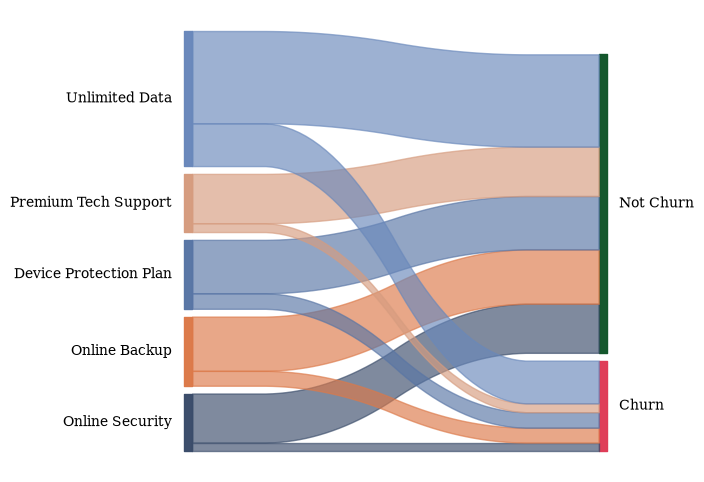

In [35]:
df1 = df.copy()
for i in ['Online Security','Online Backup','Device Protection Plan','Premium Tech Support','Unlimited Data']:
    df1[i]=df1[i].replace(to_replace='Yes',value=i)

bucket = []

for i in ['Online Security','Online Backup','Device Protection Plan','Premium Tech Support','Unlimited Data']:
    bucket.append(df1[df1[i]!='No'][[i,'Churn Label']].rename(columns={i:'Label'}))


sankey_data = pd.concat(bucket, axis=0, ignore_index=True)
sankey_data['Churn Label'] = sankey_data['Churn Label'].map({'No':'Not Churn','Yes':'Churn'})

color_palette = ["#3A4C6A","#dc7949","#5875A5", "#d69c7f","#6988BB", "#e9c5b3"]

colorDict = {
    'Online Security':"#3A4C6A",
    'Online Backup':'#dc7949',
    'Device Protection Plan':'#5875A5',
    'Premium Tech Support':'#d69c7f',
    'Unlimited Data':'#6988BB',
    'Churn':'#df3b57',
    'Not Churn':'#12562a'
}
sankey(sankey_data['Label'], sankey_data['Churn Label'], colorDict=colorDict, fontsize=10, 
       aspect=100,
       )

In [36]:
association_var =['Unlimited Data', 'Premium Tech Support', 'Device Protection Plan', 'Online Backup', 'Online Security', 'Satisfaction Score', 'Churn Label']

dict_frame = {}
for j in association_var:
    series_list = []
    for i in association_var: 
        result = association(pd.crosstab(df[j], df[i]), method="cramer")
        series_list.append(pd.Series(np.round(result, 2), index=[i]))
    dict_frame[j] = pd.concat(series_list)
dict_frame = pd.DataFrame(dict_frame)
dict_frame

,Unlimited Data,Premium Tech Support,Device Protection Plan,Online Backup,Online Security,Satisfaction Score,Churn Label
Unlimited Data,1.00,0.25,0.30,0.28,0.27,0.22,0.17
Premium Tech Support,0.25,1.00,0.33,0.29,0.35,0.17,0.16
Device Protection Plan,0.30,0.33,1.00,0.30,0.28,0.10,0.07
Online Backup,0.28,0.29,0.30,1.00,0.28,0.11,0.08
Online Security,0.27,0.35,0.28,0.28,1.00,0.32,0.17
Satisfaction Score,0.22,0.17,0.10,0.11,0.32,1.00,0.86
Churn Label,0.17,0.16,0.07,0.08,0.17,0.86,1.00


In [37]:
fig = px.imshow(dict_frame,
                text_auto=True,
                aspect='equal',
                color_continuous_scale='RdBu'#['#12562a','white','#D83C28']
                )
fig.update_layout(
    autosize=False,
    width=700,
    height=600,
        margin=dict(
        l=0,
        r=0,
        b=0,
        t=0,
        pad=0
        ),
    #plot_bgcolor='white',
)
fig.update_traces(textfont_size=17)
fig.show()

In [38]:
serv_ops = []
for i in ['Unlimited Data', 'Device Protection Plan', 'Online Backup', 'Online Security', 'Premium Tech Support']:
    group = df[df[i] == 'Yes'].groupby(by=['Satisfaction Score'])[[i]].count()
    
    group[f'{i}_Percent'] = [f'{np.round((k/group[i].sum())*100, 2)}%' for k in group[i]]
    serv_ops.append(group)
serv_ops = pd.concat(serv_ops, axis=1).reset_index()
serv_ops

,Satisfaction Score,Unlimited Data,Unlimited Data_Percent,Device Protection Plan,Device Protection Plan_Percent,Online Backup,Online Backup_Percent,Online Security,Online Security_Percent,Premium Tech Support,Premium Tech Support_Percent
0,1,764,16.1%,281,11.6%,266,10.95%,247,12.23%,161,7.88%
1,2,411,8.66%,144,5.95%,148,6.09%,39,1.93%,88,4.31%
2,3,1868,39.37%,1007,41.58%,1027,42.28%,1088,53.89%,928,45.4%
3,4,1138,23.98%,683,28.2%,688,28.32%,619,30.66%,631,30.87%
4,5,564,11.89%,307,12.68%,300,12.35%,26,1.29%,236,11.55%


In [39]:
vars = ['Unlimited Data', 'Device Protection Plan', 'Online Backup', 'Online Security', 'Premium Tech Support']

percent = ['Unlimited Data_Percent','Device Protection Plan_Percent','Online Backup_Percent','Online Security_Percent','Premium Tech Support_Percent']

color_rating = ["#DB6008","#DD7023","#D88245", "#D68E5A","#E1AB85"] #['#3A4C6A','#617088','#8994A6', '#B0B7C3','#D8DBE1']

fig = go.Figure(data=[
    go.Bar(name='1', x=vars, y=serv_ops.loc[[0]][vars].values.tolist()[0], marker_color='#DB6008' , text=serv_ops.loc[[0]][percent].values.tolist()[0]),
    go.Bar(name='2', x=vars, y=serv_ops.loc[[1]][vars].values.tolist()[0], marker_color='#DD7023', text=serv_ops.loc[[1]][percent].values.tolist()[0]),
    go.Bar(name='3', x=vars, y=serv_ops.loc[[2]][vars].values.tolist()[0] , marker_color='#D88245', text=serv_ops.loc[[2]][percent].values.tolist()[0]),
    go.Bar(name='4', x=vars, y=serv_ops.loc[[3]][vars].values.tolist()[0], marker_color='#D68E5A' , text=serv_ops.loc[[3]][percent].values.tolist()[0]),
    go.Bar(name='5', x=vars, y=serv_ops.loc[[4]][vars].values.tolist()[0], marker_color='#E1AB85', text=serv_ops.loc[[4]][percent].values.tolist()[0] ),
])

# Change the bar mode
fig.update_layout(barmode='group',
                  template='plotly_white',
                  autosize=False, width=1000, height=500, margin=dict(l=50, r=50, b=50, t=50, pad=0),
                  title=dict(text='Service Options', x=0.5, y=0.965),
                  #plot_bgcolor='white',
                  showlegend=True,
                  yaxis={'categoryorder':'total ascending'},
                  legend=dict(title='Customer Rating: ', yanchor="top", y=0.96, xanchor="left", x=0.837),
                  )
fig.update_traces(textfont_size=12, textangle=0, cliponaxis=False, textposition="outside", textfont_color='black')
fig.show()

#### Internet Additional Service vs Churn Label

In [40]:
pd.crosstab(df['Unlimited Data'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Unlimited Data,,
No,84.03,15.97
Yes,68.35,31.65


In [41]:
chi_vis(df['Unlimited Data'])
display(df[df['Internet Service'] == 'Yes']['Unlimited Data'].value_counts())

Unlimited Data
Yes    4745
No      772
Name: count, dtype: int64

In [42]:
pd.crosstab(df['Device Protection Plan'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Device Protection Plan,,
No,71.35,28.65
Yes,77.50,22.50


In [43]:
chi_vis(df['Device Protection Plan'])
display(df[df['Internet Service'] == 'Yes']['Device Protection Plan'].value_counts())

Device Protection Plan
No     3095
Yes    2422
Name: count, dtype: int64

In [44]:
pd.crosstab(df['Online Backup'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Online Backup,,
No,70.83,29.17
Yes,78.47,21.53


In [45]:
chi_vis(df['Online Backup'])
display(df[df['Internet Service'] == 'Yes']['Online Backup'].value_counts())

Online Backup
No     3088
Yes    2429
Name: count, dtype: int64

In [46]:
pd.crosstab(df['Online Security'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Online Security,,
No,68.67,31.33
Yes,85.39,14.61


In [47]:
chi_vis(df['Online Security'])
display(df[df['Internet Service'] == 'Yes']['Online Security'].value_counts())

Online Security
No     3498
Yes    2019
Name: count, dtype: int64

In [48]:
pd.crosstab(df['Online Security'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Online Security,,
No,68.67,31.33
Yes,85.39,14.61


In [49]:
chi_vis(df['Premium Tech Support'])
display(df[df['Internet Service'] == 'Yes']['Premium Tech Support'].value_counts())

Premium Tech Support
No     3473
Yes    2044
Name: count, dtype: int64

### Contract

In [50]:
df['Tenure in Months'].describe()

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure in Months, dtype: float64

In [51]:
chi_vis(df_internet_type['Contract'], df_internet_type['Churn Label'], width=600, save=True)

Saved as ../images/churn_contract.svg


In [52]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Contract,,
Month-to-Month,54.16,45.84
One Year,89.29,10.71
Two Year,97.45,2.55


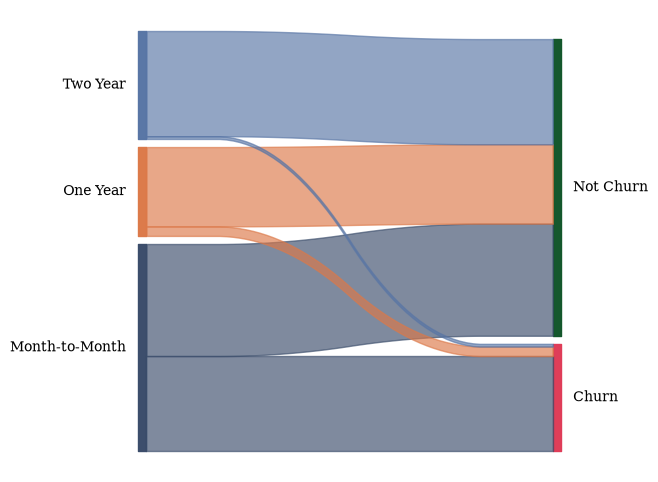

In [53]:
color_palette = ["#3A4C6A","#dc7949","#5875A5", "#d69c7f","#6988BB", "#e9c5b3"] # [#3A4C6A, #dc7949]
colorDict = {
    'Two Year':'#5875A5',
    'One Year':'#dc7949',
    'Month-to-Month':'#3A4C6A',
    'Churn':'#df3b57',
    'Not Churn':'#12562a'
}

sankey(df['Contract'], df['Churn Label'].replace({'Yes': 'Churn', 'No': 'Not Churn'}), colorDict=colorDict, fontsize=10, aspect=100)

In [54]:
pd.crosstab(df['Payment Method'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,66.00,34.00
Credit Card,85.52,14.48
Mailed Check,63.12,36.88


In [55]:
chi_vis(df['Payment Method'], width=600)

### Offer

In [56]:
chi_vis(df_internet_type['Offer'], df_internet_type['Churn Label'], width=650, save=True)

Saved as ../images/churn_offer.svg


In [57]:
pd.crosstab(df['Offer'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Offer,,
None,72.89,27.11
Offer A,93.27,6.73
Offer B,87.74,12.26
Offer C,77.11,22.89
Offer D,73.26,26.74
Offer E,47.08,52.92


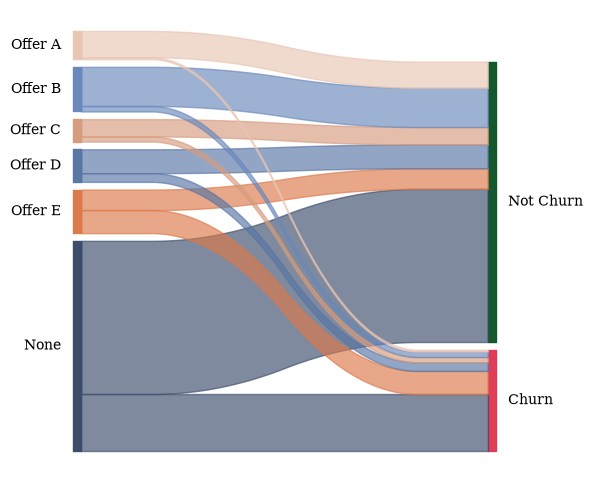

In [58]:
color_palette = ["#3A4C6A","#dc7949","#5875A5", "#d69c7f","#6988BB", "#e9c5b3"] # [#3A4C6A, #dc7949]


colorDict = {
    'Offer E':'#dc7949',
    'Offer D':'#5875A5',
    'Offer C':'#d69c7f',
    'Offer B':'#6988BB',
    'Offer A':'#e9c5b3',
    'None':'#3A4C6A',
    'Churn':'#df3b57',
    'Not Churn':'#12562a'
}

sankey(df['Offer'], df['Churn Label'].replace({'Yes': 'Churn', 'No': 'Not Churn'}), colorDict=colorDict, fontsize=10, aspect=100)

### Total Revenue Loss

In [59]:
revenue = df.groupby(by='Churn Label', as_index=False)['Total Revenue'].sum().replace({'No':'Not Churn','Yes':'Churn'})
revenue['Percent'] = [np.round(i / revenue['Total Revenue'].sum()*100, 2) for i in revenue['Total Revenue']] 

fig = px.pie(revenue, values='Total Revenue', names='Churn Label', color_discrete_sequence=['#12562a','#D83C28'])

fig.update_layout(autosize=False, width=500, height=500, 
                  margin=dict(l=20, r=10, b=10, t=50, pad=20),
                  title=dict(text='Churn Revenue Distribution', x=0.5),
                  plot_bgcolor='white',
                  showlegend=True, legend=dict(x=0.85, y=0.98)
                  )
fig.update_traces(textfont_size=20,text=[f'{int(np.round(i)):,} $' for i in revenue['Total Revenue']],textinfo='percent+text')
fig.show()